In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

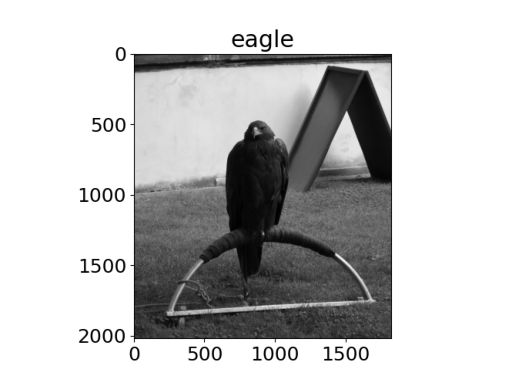

<class 'numpy.ndarray'>
(480, 640, 3)


In [2]:
img = cv2.imread('images/input.jpg')

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.axis('off')
plt.show()
print(type(img))
print(img.shape)

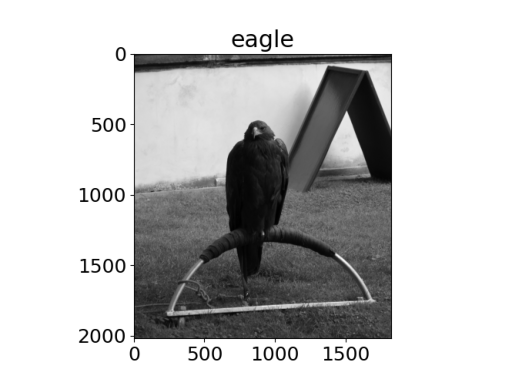

True

In [3]:
gray_img = cv2.imread('images/input.jpg', cv2.IMREAD_GRAYSCALE)

plt.imshow(gray_img, cmap='gray')
plt.axis('off')
plt.show()
cv2.imwrite('images/output_gray.jpg', gray_img)

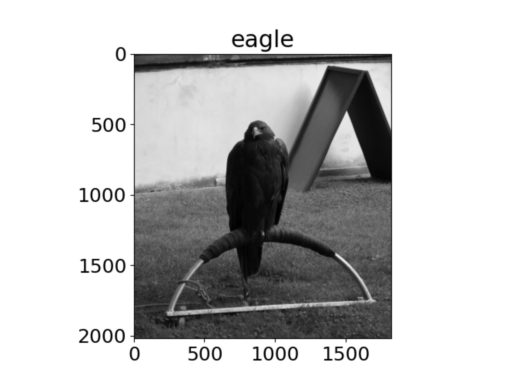

Original: (480, 640, 3)
new double size: (960, 1280, 3)


True

In [4]:
# Increase the image  size , fx =2 to double the width and soo on
bigger_img = cv2.resize(
    img,
    None,
    fx=2,
    fy=2,
    interpolation=cv2.INTER_LINEAR
)

# Converttion to display in Jupyter
bigger_rgb = cv2.cvtColor(bigger_img, cv2.COLOR_BGR2RGB)

plt.imshow(bigger_rgb)
plt.axis('off')
plt.show()
print("Original:", img.shape)
print("new double size:", bigger_img.shape)
cv2.imwrite('images/resized_image.jpg', bigger_img)

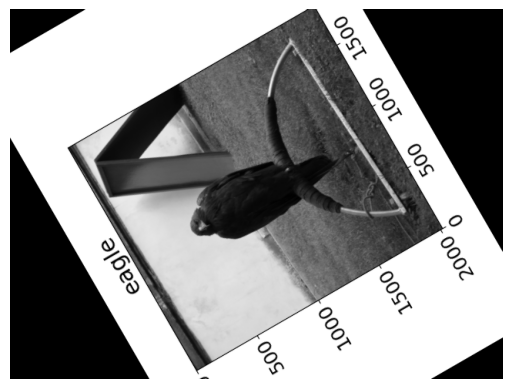

True

In [5]:
#Rotation
height, width = img.shape[:2]

#Find the center of the image
center = (width // 2, height // 2)

# Rotate the image
rotation_matrix = cv2.getRotationMatrix2D(center, 120, 1.0)
rotated_img = cv2.warpAffine(img, rotation_matrix, (width, height))

# Convert BGR to RGB for Jupyter display 
rotated_rgb = cv2.cvtColor(rotated_img, cv2.COLOR_BGR2RGB)

plt.imshow(rotated_rgb)
plt.axis('off')
plt.show()

cv2.imwrite('images/rotated_120.jpg', rotated_img)

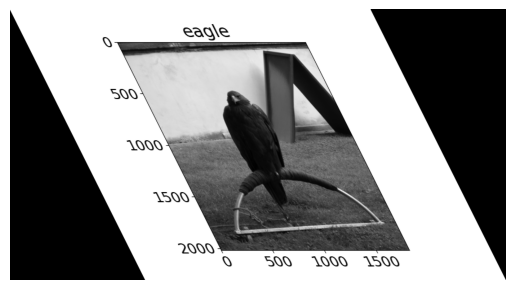

True

In [6]:
#Shear the image horizontally
height, width = img.shape[:2]

#Shear factor
shear_factor = 0.5

#Shear transformation matrix
shear_matrix = np.float32([
    [1, shear_factor, 0],
    [0, 1, 0]
])

# New width so the image does not get cut off
new_width = int(width + abs(shear_factor * height))

# Apply shear transformation
sheared_img = cv2.warpAffine(
    img,
    shear_matrix,
    (new_width, height)
)

sheared_rgb = cv2.cvtColor(sheared_img, cv2.COLOR_BGR2RGB)

plt.imshow(sheared_rgb)
plt.axis('off')
plt.show()

cv2.imwrite('images/sheared_image.jpg', sheared_img)

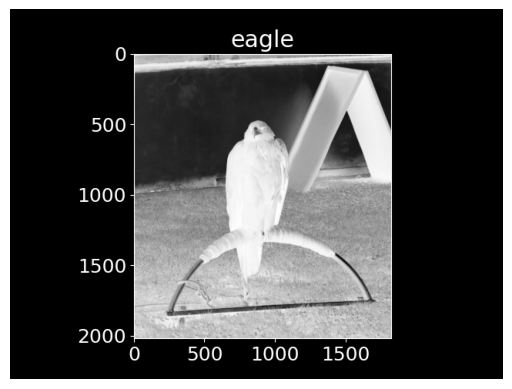

True

In [7]:
negative_img = 255 - gray_img

plt.imshow(negative_img, cmap='gray')
plt.axis('off')
plt.show()

cv2.imwrite('images/negative_image.jpg', negative_img)

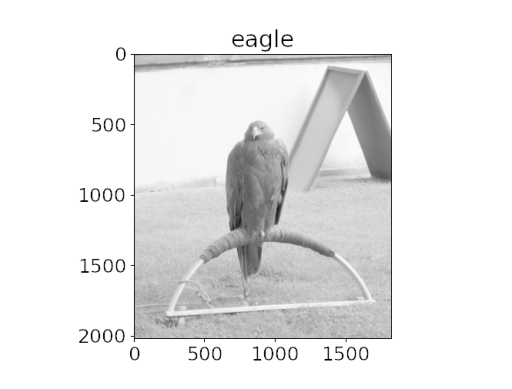

True

In [8]:
gray_float = gray_img.astype(np.float32)

c = 255 / np.log(1 + np.max(gray_float))

log_img = c * np.log(1 + gray_float)
log_img = np.uint8(log_img)

plt.imshow(log_img, cmap='gray')
plt.axis('off')
plt.show()

cv2.imwrite('images/log_image.jpg', log_img)

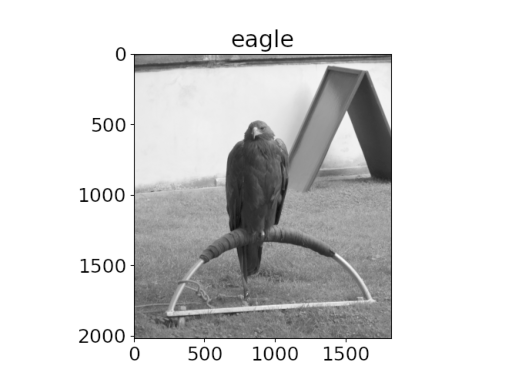

True

In [9]:
gamma = 0.5

normalized_img = gray_img / 255.0
power_img = np.power(normalized_img, gamma)
power_img = np.uint8(power_img * 255)

plt.imshow(power_img, cmap='gray')
plt.axis('off')
plt.show()

cv2.imwrite('images/power_law_image.jpg', power_img)